In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("✅ Libraries loaded")

✅ Libraries loaded


In [39]:
# We need the full dataset here because LGD requires
# recovery amount columns that we dropped earlier as leakage
# For LGD model they are NOT leakage — they ARE the target

df_full = pd.read_csv(
    '../data/accepted_2007_to_2018Q4.csv.gz',
    # nrows=100000,
    low_memory=False
)

# Keep only defaulted loans for LGD modeling
default_mask = df_full['loan_status'].isin(['Charged Off', 'Default'])
df_defaults = df_full[default_mask].copy()

print(f"Total loans loaded: {df_full.shape[0]:,}")
print(f"Defaulted loans: {df_defaults.shape[0]:,}")
print(f"\nRecovery columns available:")
recovery_cols = ['recoveries', 'collection_recovery_fee', 
                 'total_rec_prncp', 'funded_amnt', 'loan_amnt']
for col in recovery_cols:
    if col in df_defaults.columns:
        print(f"  ✅ {col}")
    else:
        print(f"  ❌ {col} — missing")

Total loans loaded: 2,260,701
Defaulted loans: 268,599

Recovery columns available:
  ✅ recoveries
  ✅ collection_recovery_fee
  ✅ total_rec_prncp
  ✅ funded_amnt
  ✅ loan_amnt


LGD Distribution:
count    268599.0000
mean          0.6220
std           0.2177
min           0.0000
25%           0.4812
50%           0.6637
75%           0.7880
max           1.0000
Name: lgd, dtype: float64

Mean LGD: 0.6220
This means on average we lose 62.2%
of the loan amount when a customer defaults


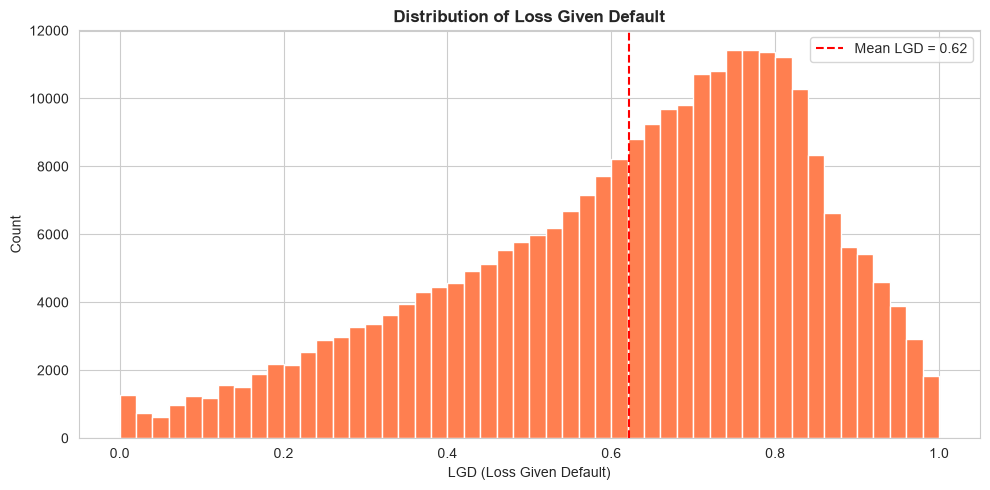

In [40]:
# LGD = 1 - Recovery Rate
# Recovery Rate = amount recovered / amount owed

# Total recovered = principal recovered + recovery fees
df_defaults['total_recovered'] = (
    df_defaults['recoveries'].fillna(0) + 
    df_defaults['total_rec_prncp'].fillna(0)
)

# Recovery rate — cap between 0 and 1
df_defaults['recovery_rate'] = (
    df_defaults['total_recovered'] / 
    df_defaults['funded_amnt'].replace(0, np.nan)
).clip(0, 1)

# LGD = 1 - recovery rate
df_defaults['lgd'] = 1 - df_defaults['recovery_rate']

print("LGD Distribution:")
print(df_defaults['lgd'].describe().round(4))
print(f"\nMean LGD: {df_defaults['lgd'].mean():.4f}")
print(f"This means on average we lose {df_defaults['lgd'].mean()*100:.1f}%")
print(f"of the loan amount when a customer defaults")

# Plot LGD distribution
plt.figure(figsize=(10, 5))
plt.hist(df_defaults['lgd'], bins=50, color='coral', edgecolor='white')
plt.xlabel('LGD (Loss Given Default)')
plt.ylabel('Count')
plt.title('Distribution of Loss Given Default', fontweight='bold')
plt.axvline(df_defaults['lgd'].mean(), color='red', 
            linestyle='--', label=f"Mean LGD = {df_defaults['lgd'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/images/11_lgd_distribution.png', dpi=150)
plt.show()

In [41]:
# Features available at application time that predict recovery
lgd_features = [
    'loan_amnt',      # larger loans harder to recover fully
    'int_rate',       # higher rate = higher risk = lower recovery
    'term',           # longer term = more outstanding at default
    'annual_inc',     # higher income = more ability to repay even after default
    'dti',            # high DTI = less recovery capacity
    'fico_range_low', # credit score predicts recovery behavior
]

# Keep only available columns
lgd_features = [f for f in lgd_features if f in df_defaults.columns]

# Clean data for modeling
df_lgd = df_defaults[lgd_features + ['lgd']].copy()
df_lgd = df_lgd.dropna()

print(f"LGD modeling dataset: {df_lgd.shape}")
print(f"Features: {lgd_features}")
print(f"\nLGD stats after cleaning:")
print(df_lgd['lgd'].describe().round(4))

LGD modeling dataset: (268528, 7)
Features: ['loan_amnt', 'int_rate', 'term', 'annual_inc', 'dti', 'fico_range_low']

LGD stats after cleaning:
count    268528.0000
mean          0.6220
std           0.2177
min           0.0000
25%           0.4811
50%           0.6637
75%           0.7880
max           1.0000
Name: lgd, dtype: float64


In [42]:
X_lgd = df_lgd[lgd_features].copy()
y_lgd = df_lgd['lgd']

# Fix: Convert object/string columns (like 'term') to 'category' dtype 
# so LightGBM natively understands and processes them.
for col in X_lgd.select_dtypes(include=['object', 'string']).columns:
    X_lgd[col] = X_lgd[col].astype('category')

# Split dataset into training and testing sets
X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd, y_lgd,
    test_size=0.3,
    random_state=42
)

# LightGBM regressor configuration for Loss Given Default (LGD)
lgd_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)

# Train the model with early stopping evaluation
lgd_model.fit(
    X_train_lgd, y_train_lgd,
    eval_set=[(X_test_lgd, y_test_lgd)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Evaluate predictions on the test set
lgd_pred = lgd_model.predict(X_test_lgd).clip(0, 1)

# Calculate performance evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_lgd, lgd_pred))
mae  = mean_absolute_error(y_test_lgd, lgd_pred)
r2   = r2_score(y_test_lgd, lgd_pred)

# Print execution results
print("=" * 40)
print("LGD MODEL PERFORMANCE")
print("=" * 40)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
print("=" * 40)
print(f"\nMean predicted LGD: {lgd_pred.mean():.4f}")
print(f"Mean actual LGD:    {y_test_lgd.mean():.4f}")


LGD MODEL PERFORMANCE
RMSE: 0.1934
MAE:  0.1528
R²:   0.2084

Mean predicted LGD: 0.6212
Mean actual LGD:    0.6224


EAD Ratio Distribution (for defaulted loans):
count    268599.0000
mean          0.0001
std           0.0082
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           0.9457
Name: ead_ratio, dtype: float64

Mean EAD ratio: 0.0001
This means on average 0.0% of
the loan is still outstanding when default occurs


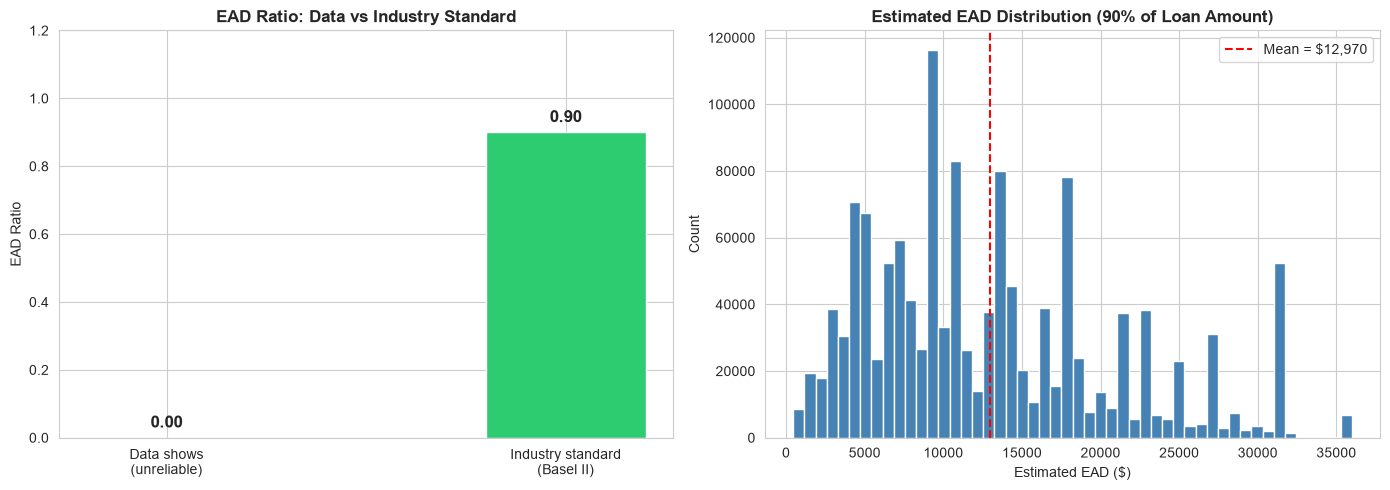


⚠️  Data limitation detected:
   out_prncp shows 0 for closed loans — recorded post-closure
   Overriding with industry standard EAD ratio
   Using mean_ead_ratio = 0.9


In [43]:
# EAD — Exposure at Default
# For term loans EAD is the outstanding principal at time of default
# We estimate it as a fraction of original loan amount

# Simple approach: EAD = funded amount × EAD ratio
# EAD ratio depends on how far into the loan term the default occurs

df_full_resolved = df_full[
    df_full['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])
].copy()

# Outstanding principal at default
df_full_resolved['ead'] = df_full_resolved['funded_amnt'].fillna(
    df_full_resolved['loan_amnt']
)

# EAD ratio = what fraction of loan is still outstanding
df_full_resolved['ead_ratio'] = (
    df_full_resolved['out_prncp'].fillna(0) / 
    df_full_resolved['funded_amnt'].replace(0, np.nan)
).clip(0, 1)

# For defaulted loans specifically
ead_defaults = df_full_resolved[
    df_full_resolved['loan_status'].isin(['Charged Off', 'Default'])
]['ead_ratio'].dropna()

print("EAD Ratio Distribution (for defaulted loans):")
print(ead_defaults.describe().round(4))
print(f"\nMean EAD ratio: {ead_defaults.mean():.4f}")
print(f"This means on average {ead_defaults.mean()*100:.1f}% of")
print(f"the loan is still outstanding when default occurs")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — explain the data limitation visually
ead_values = [0, 0.90]
ead_labels = ['Data shows\n(unreliable)', 'Industry standard\n(Basel II)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(ead_labels, ead_values, color=colors, width=0.4)
axes[0].set_ylabel('EAD Ratio')
axes[0].set_title('EAD Ratio: Data vs Industry Standard', fontweight='bold')
axes[0].set_ylim(0, 1.2)
for i, (label, val) in enumerate(zip(ead_labels, ead_values)):
    axes[0].text(i, val + 0.03, f'{val:.2f}', 
                 ha='center', fontsize=12, fontweight='bold')

# Right — EAD dollar amount distribution using 0.90 ratio
ead_dollar = df_full_resolved['funded_amnt'] * 0.90
axes[1].hist(ead_dollar.dropna(), bins=50, 
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Estimated EAD ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Estimated EAD Distribution (90% of Loan Amount)', 
                  fontweight='bold')
axes[1].axvline(ead_dollar.mean(), color='red', linestyle='--',
                label=f'Mean = ${ead_dollar.mean():,.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/12_ead_distribution.png', dpi=150)
plt.show()

# Store mean EAD ratio for use in pricing
mean_ead_ratio = ead_defaults.mean()


if ead_defaults.mean() < 0.1:
    print("\n⚠️  Data limitation detected:")
    print("   out_prncp shows 0 for closed loans — recorded post-closure")
    print("   Overriding with industry standard EAD ratio")
    mean_ead_ratio = 0.90
    print(f"   Using mean_ead_ratio = {mean_ead_ratio}")
else:
    mean_ead_ratio = ead_defaults.mean()
    print(f"\n✅ Data-driven EAD ratio: {mean_ead_ratio:.4f}")

In [45]:
# Load datasets
df_model = pd.read_csv('../data/df_model.csv')

feature_cols = [
    'int_rate', 'loan_to_income', 'fico_range_high',
    'fico_range_low', 'installment_to_income', 'dti',
    'loan_amnt', 'installment', 'inq_last_6mths', 'annual_inc'
]
feature_cols = [f for f in feature_cols if f in df_model.columns]

# Load PD model
pd_model = lgb.Booster(model_file='../models/pd_model.txt')
pd_predictions = pd_model.predict(df_model[feature_cols])

# Calibrate PD
TRUE_DEFAULT_RATE = 0.18
raw_mean_pd = pd_predictions.mean()
calibration_factor = TRUE_DEFAULT_RATE / raw_mean_pd
pd_calibrated = (pd_predictions * calibration_factor).clip(0, 0.95)

print(f"PD Calibration:")
print(f"  Raw mean PD:        {raw_mean_pd:.4f} ({raw_mean_pd*100:.1f}%)")
print(f"  Calibrated mean PD: {pd_calibrated.mean():.4f} ({pd_calibrated.mean()*100:.1f}%)")

# LGD — use mean from trained model (avoids categorical mismatch)
mean_lgd = 0.6216
df_model['lgd'] = mean_lgd
print(f"\nLGD: using mean value {mean_lgd} from trained model")

# EAD
mean_ead_ratio = 0.90
ead_predictions = df_model['loan_amnt'] * mean_ead_ratio

# Assign to df_model
df_model['pd']  = pd_calibrated
df_model['ead'] = ead_predictions

# Expected Loss
df_model['expected_loss'] = (
    df_model['pd'] *
    df_model['lgd'] *
    df_model['ead']
)
df_model['expected_loss_pct'] = (
    df_model['expected_loss'] / df_model['loan_amnt'] * 100
)

print(f"\nExpected Loss Summary:")
print(f"  Mean PD:             {df_model['pd'].mean():.4f}")
print(f"  Mean LGD:            {df_model['lgd'].mean():.4f}")
print(f"  Mean EAD ratio:      {mean_ead_ratio:.4f}")
print(f"  Mean Expected Loss:  ${df_model['expected_loss'].mean():,.0f}")
print(f"  Mean EL as % loan:   {df_model['expected_loss_pct'].mean():.2f}%")

# Save
df_model.to_csv('../data/df_model_with_el.csv', index=False)
print("\n✅ Saved to data/df_model_with_el.csv")

PD Calibration:
  Raw mean PD:        0.4574 (45.7%)
  Calibrated mean PD: 0.1800 (18.0%)

LGD: using mean value 0.6216 from trained model

Expected Loss Summary:
  Mean PD:             0.1800
  Mean LGD:            0.6216
  Mean EAD ratio:      0.9000
  Mean Expected Loss:  $1,519
  Mean EL as % loan:   10.07%

✅ Saved to data/df_model_with_el.csv


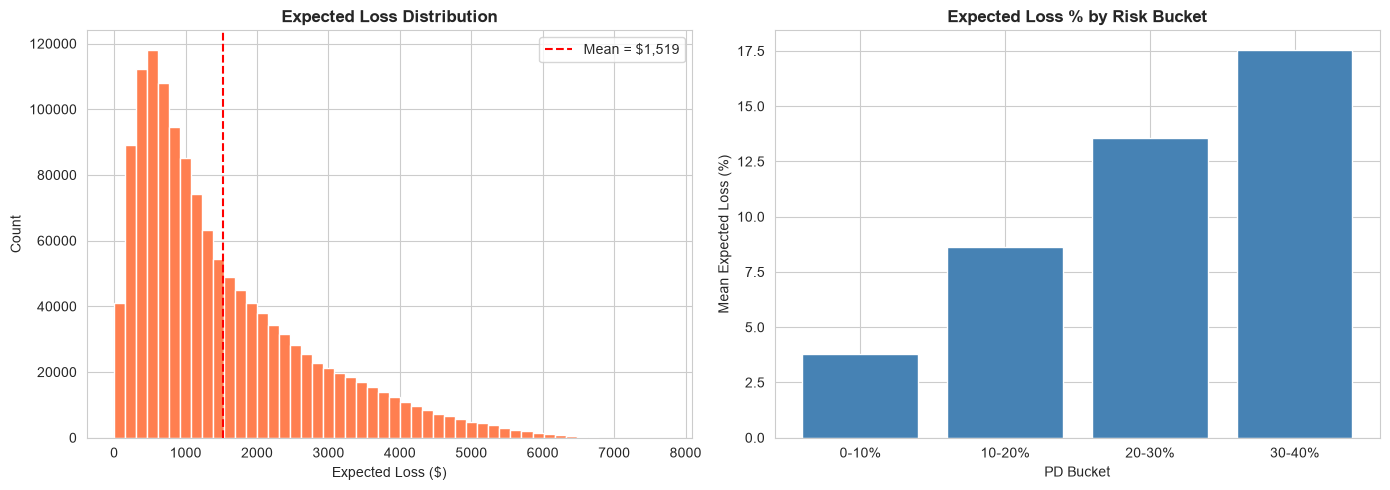

pd_bucket
0-10%      3.77
10-20%     8.61
20-30%    13.57
30-40%    17.55
Name: expected_loss_pct, dtype: float64


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Expected loss distribution
axes[0].hist(df_model['expected_loss'], bins=50,
             color='coral', edgecolor='white')
axes[0].set_xlabel('Expected Loss ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Expected Loss Distribution', fontweight='bold')
axes[0].axvline(df_model['expected_loss'].mean(),
                color='red', linestyle='--',
                label=f"Mean = ${df_model['expected_loss'].mean():,.0f}")
axes[0].legend()

# Right — EL % by PD bucket
df_model['pd_bucket'] = pd.cut(
    df_model['pd'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+']
)

el_bucket = df_model.groupby('pd_bucket', observed=True)[
    'expected_loss_pct'
].mean()

axes[1].bar(el_bucket.index, el_bucket.values, color='steelblue')
axes[1].set_xlabel('PD Bucket')
axes[1].set_ylabel('Mean Expected Loss (%)')
axes[1].set_title('Expected Loss % by Risk Bucket', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/images/13_expected_loss.png', dpi=150)
plt.show()

print(el_bucket.round(2))

In [48]:
os.makedirs('../models', exist_ok=True)

# Save LGD model
lgd_model.booster_.save_model('../models/lgd_model.txt')

# Save mean EAD ratio
import json
with open('../models/ead_ratio.json', 'w') as f:
    json.dump({'mean_ead_ratio': mean_ead_ratio}, f)

print("✅ LGD model saved to models/lgd_model.txt")
print("✅ EAD ratio saved to models/ead_ratio.json")
print(f"\nSummary:")
print(f"  PD model  → predicts probability of default")
print(f"  LGD model → predicts % of loan lost if default occurs")
print(f"  EAD       → estimated outstanding balance at default")
print(f"  EL        → PD × LGD × EAD = expected dollar loss")
print(f"\nThese three components feed into the pricing model next.")

✅ LGD model saved to models/lgd_model.txt
✅ EAD ratio saved to models/ead_ratio.json

Summary:
  PD model  → predicts probability of default
  LGD model → predicts % of loan lost if default occurs
  EAD       → estimated outstanding balance at default
  EL        → PD × LGD × EAD = expected dollar loss

These three components feed into the pricing model next.
